# Introducción al Aprendizaje Automático: Taller 2
**Equipo: MCMC Metropolis**
* Felipe Asbún - 202010509-K - felipe.asbun@usm.cl
* Ignacio Allendes - 202004531-3 - ignacio.allendesm@usm.cl

Vídeo:
https://youtu.be/3rfkY7mDqOk

### **Declaración ética**
Declaramos que el trabajo realizado es original. Todos los miembros contribuyeron en todas las áreas, destacando el aporte de Felipe en Cross Validation con Stratified K-Fold y a Ignacio en enriquecimiento de datos.

## Predicción de Riesgo Crediticio

El objetivo de este taller es que se familiciaricen con competencias/desafíos en ciencia de datos y machine learning. Por lo tanto, la actividad es abierta y requiere diseñar, implementar, y evaluar una solución a un problema real usando técnicas estudiadas en el curso.


<table align='left'>
<tr>
<td><img src='https://content.pymnts.com/wp-content/uploads/2019/02/Aire-AI-Credit-Scoring-1000x600.jpg' width='900'/> </td>
</tr>
</table>

## Introducción

La tecnología financiera (*fintech*) es un conjunto de productos y servicios que aprovechan avances tecnOlógicos recientes para resolver problemas o mejorar procesos actuales en la industria financiera. Este sector representa una de las áreas laborales de mayor crecimiento reciente.

El aprendizaje automático en fintech implica la aplicación de algoritmos y modelos avanzados para analizar datos financieros, hacer predicciones, automatizar procesos y optimizar la toma de decisiones en la industria financiera. Permite a las instituciones financieras mejorar la evaluación de riesgos, la detección de fraudes, el servicio al cliente, las estrategias de inversión y más, aprovechando el poder de los datos y la automatización.

## Problema & Datos

> **Problema:** En este desafío exploraremos el problema de predecir si una solicitud de crédito a un banco será pagada o no, una versión binaria de lo que se denomina análisis de riesgo, que es su vez una de las aplicaciones más comunes del aprendizaje automático en la industria financiera.

> **Materiales:** Usted dispondrá de varias tablas extraídas de una base de datos relacional que describe el comportamiento previo de los clientes en una entidad financiera real. La solución del desafío requiere emplear técnicas de fusión de datos para crear un dataset que pueda ser utilizado por modelos clásicos de aprendizaje automático. Como en muchos problemas reales, la construcción de una solución requerirá también de una limpieza de datos, de un método para tratar datos faltantes, de un buen análisis exploratorio de datos, y de una creativa ingeniería de atributos.

## Métrica

La métrica de la competencia será [AUC](https://es.wikipedia.org/wiki/Curva_ROC) ó área bajo la curva ROC.

$$\operatorname{TPR}(T): T \to y(x)$$
$$\operatorname{FPR}(T): T \to x$$

\begin{aligned}
A & = \int_{x=0}^{1}{\mbox{TPR}(\mbox{FPR}^{-1}(x)) dx}\\
& = \int_{\infty}^{-\infty} \mbox{TPR}(T) \mbox{FPR}'(T) \, dT\\
& = \int_{-\infty}^\infty \int_{-\infty}^\infty I(T' \ge T)f_1(T') f_0(T) \, dT' \, dT = P(X_1 \ge X_0)
\end{aligned}



## Base Imports

In [ ]:
# Plotting libraries
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt
# Scikit learn
import sklearn.preprocessing as skp
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
# Scikit Metrics
from sklearn.metrics import log_loss, classification_report, accuracy_score, f1_score, roc_auc_score
# Data manipulation libraries
import pandas as pd
import numpy as np
import scipy
# General use
from tqdm.notebook import tqdm
from joblib import dump, load
import warnings
warnings.filterwarnings("ignore")


# Si quiere trabajar en local cambiar a False
COLAB_FLAG = True

In [ ]:
# pip install -U scikit-learn

## Carga de Datos

Como es usual, debe cargar los archivos distribuidos con esta tarea en la máquina virtual o en la máquina local donde trabajará, sustituyendo las rutas mostradas como ejemplo por las rutas donde tiene alojados los archivos.

In [ ]:
data_path = '/local_path_to_data/'

if COLAB_FLAG:
  print("Mounting your Google Drive ...")

  from google.colab import drive
  drive.flush_and_unmount()
  drive.mount('/content/drive', force_remount=True)

  data_path = "/content/drive/MyDrive/Colab Notebooks/data_taller_2/"

Mounting your Google Drive ...
Mounted at /content/drive


## Unzip Data Files

In [ ]:
# !unzip data_path+'*.zip' -d data_path

Movemos y renombramos la carpeta a la ubicación que queramos

In [ ]:
# !mv content/file_data/ train_data/

## Funciones útiles

Estas funciones son adheridas al notebook con tal de ayudar en la inspiración de visualizaciones útiles, facilitando así el encontrar patrones para unificar las tablas.

In [ ]:
def numeric_columns(df):
  numeric_columns = []
  for column in df.columns.tolist():
    if df.dtypes[column] != 'object':
      numeric_columns.append(column)
  return numeric_columns

def plot_numeric_data(df, nrows=3, ncols=4, exclude_columns=['SK_ID_BUREAU', 'SK_ID_CURR']):
  fig, ax = plt.subplots(figsize=(16, 18), nrows=nrows, ncols=ncols)
  cont = 0
  for idx, column in enumerate(tqdm(numeric_columns(df))):
    if df.dtypes[column] != 'object' and column not in exclude_columns:
      df[column].plot(kind='kde',
                      xlabel=column,
                      ax=ax[(idx + cont)//4, (idx + cont)%4])
      ax[(idx + cont)//4, (idx + cont)%4].set_xlabel(column, fontsize=8)
    else:
      cont -= 1

  plt.subplots_adjust(bottom=.25, left=.25)
  plt.tight_layout()
  plt.show()

# Descripción de las columnas
def dataframe_columns_description(df):
  print('-' * 160)
  for index, row in description_df[description_df['Row'].isin(df)].drop('Table', axis=1).iterrows():
    print(f"|{row['Row']}: {row['Description']} ({row['Special']})" if type(row['Special']) != float else f"|{row['Row']}: {row['Description']}")
    print('-' * 160)

## Problema & Datos

In [ ]:
description_df = pd.read_csv(data_path + 'columns_description.csv', index_col=0)

loan_history_df = pd.read_csv(data_path + 'historial_prestamos.csv', index_col=0)
loan_history_movements_df = pd.read_csv(data_path + 'historial_prestamos_movimientos.csv', index_col=0)

request_test_df = pd.read_csv(data_path + 'solicitudes_test.csv', index_col=0)
request_train_df = pd.read_csv(data_path + 'solicitudes_train.csv', index_col=0)

credit_card_movements_df = pd.read_csv(data_path + 'tarjeta_credito_movimientos.csv', index_col=0)

In [ ]:
display(description_df.head())

,Table,Row,Description,Special
0,solicitud_{train/test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,solicitud_{train/test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,solicitud_{train/test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,solicitud_{train/test}.csv,CODE_GENDER,Gender of the client,NaN
4,solicitud_{train/test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [ ]:
display(loan_history_df.head())
display(loan_history_movements_df.head())

,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
SK_ID_CURR,,,,,,,,,,,,,,,,
215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


,MONTHS_BALANCE,STATUS
SK_ID_BUREAU,,
5715448,0,C
5715448,-1,C
5715448,-2,C
5715448,-3,C
5715448,-4,C


In [ ]:
display(credit_card_movements_df.head())

,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
SK_ID_PREV,,,,,,,,,,,,,,,,,,,,,
2582071,363914,-1,63975.555,45000,2250.0,2250.000,0.0,0.000,2250.00,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
1389973,337855,-4,236572.110,225000,2250.0,2250.000,0.0,0.000,11795.76,11925.000,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
1891521,126868,-1,453919.455,450000,0.0,11547.000,0.0,11547.000,22924.89,27000.000,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0
2181852,367360,-4,291543.075,292500,90000.0,289339.425,0.0,199339.425,130.50,4093.515,...,286831.575,286831.575,3.0,8,0.0,5.0,3.0,Active,0,0
1235299,203885,-5,201261.195,225000,76500.0,111026.700,0.0,34526.700,6338.34,45000.000,...,197224.695,197224.695,3.0,9,0.0,6.0,38.0,Active,0,0


In [ ]:
display(request_train_df.head())

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
331475,0,Cash loans,F,Y,Y,0,135000.0,835380.0,30955.5,675000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
366488,0,Cash loans,F,N,Y,0,103500.0,659533.5,26284.5,589500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0
444791,0,Cash loans,F,N,Y,0,135000.0,219042.0,23130.0,193500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
112960,0,Revolving loans,F,N,Y,0,67500.0,675000.0,33750.0,675000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,9.0
418735,0,Revolving loans,F,N,Y,0,315000.0,900000.0,45000.0,900000.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0


Como sugerencia al con tablas con muchos *NaNs* o también denominada *Raw Data* una opción es prescindir de aquellas columnas que posean una cantidad de *NaNs* superior a cierto *treshhold* por sobre el cual pierde sentido la utilización del dato.

A modo de ejemplo a continuación filtramos el dataset, dejando fuera toda las columnas que tengan *NaNs*.

Este filtrado debe ser realizado con especial cuidado pues se puede incurrir en la pérdida de información valiosa donde el valor perdido puede ser determinado a partir de las otras columnas o incluso las otras tablas.

- Eliminamos las columnas que superan cierto umbral de valores NaNs


In [ ]:
n_data = request_train_df.shape[0]
n_nan = request_train_df.isna().sum().apply(lambda x: x/n_data).reset_index()
n_nan.columns=['columns', '%nan']

threshold = 0.4
nan_cols = n_nan.loc[lambda x: x['%nan'] > threshold]

request_train_filtered_df = request_train_df.drop(columns=nan_cols['columns'].tolist())

display(request_train_filtered_df.head())

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
331475,0,Cash loans,F,Y,Y,0,135000.0,835380.0,30955.5,675000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
366488,0,Cash loans,F,N,Y,0,103500.0,659533.5,26284.5,589500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0
444791,0,Cash loans,F,N,Y,0,135000.0,219042.0,23130.0,193500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
112960,0,Revolving loans,F,N,Y,0,67500.0,675000.0,33750.0,675000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,9.0
418735,0,Revolving loans,F,N,Y,0,315000.0,900000.0,45000.0,900000.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0


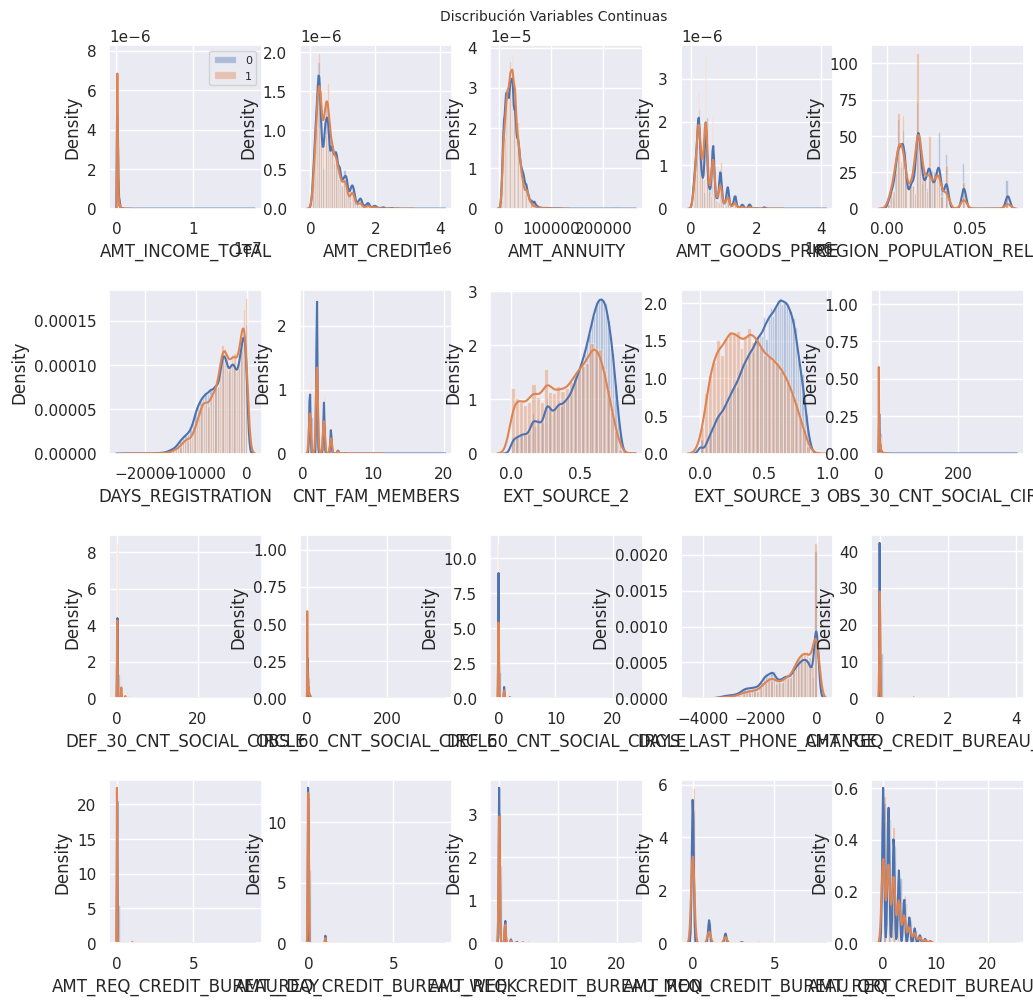

In [ ]:
request_types = request_train_filtered_df.dtypes
req_cat_att = request_types.loc[request_types == 'object'].index.tolist()
req_cont_att = request_types.loc[request_types == 'float64'].index.tolist()
req_integer_att = request_types.loc[request_types == 'int64'].index.tolist()[1:]

fig, axes = plt.subplots(figsize=(10,10), nrows=4, ncols=5)
fig.suptitle('Discribución Variables Continuas', fontsize=10)
fig.tight_layout()
fig.subplots_adjust(wspace=0.25, hspace=0.5)
for i, column in enumerate(req_cont_att):
    for t in request_train_filtered_df['TARGET'].unique():
      target = request_train_filtered_df.loc[request_train_filtered_df['TARGET'] == t]
      sns.distplot(target[column], hist=True, rug=False, kde=True,
                   ax=axes[i//5,i%5], label=t)
      if i==0:
        axes[0,0].legend(prop={'size': 8})

Limpiaremos el dataframe request_train_df. Para ello, reemplazamos en aquellos datos numéricos por la media, y en los datos categóricos por un valor nuevo, que denominamos "Unknown", que posteriormente se encodeará distinto a los valores originales del dataset.

In [ ]:
nan_filtered_cols = []
for idx, row in pd.DataFrame(request_train_filtered_df.isna().sum()).iterrows():
  if row[0] != 0:
    nan_filtered_cols.append(idx)

request_train_filtered_df[nan_filtered_cols].isna().sum()

AMT_ANNUITY                       5
AMT_GOODS_PRICE                 142
NAME_TYPE_SUITE                 631
OCCUPATION_TYPE               47367
CNT_FAM_MEMBERS                   1
EXT_SOURCE_2                    323
EXT_SOURCE_3                  29842
OBS_30_CNT_SOCIAL_CIRCLE        508
DEF_30_CNT_SOCIAL_CIRCLE        508
OBS_60_CNT_SOCIAL_CIRCLE        508
DEF_60_CNT_SOCIAL_CIRCLE        508
AMT_REQ_CREDIT_BUREAU_HOUR    20424
AMT_REQ_CREDIT_BUREAU_DAY     20424
AMT_REQ_CREDIT_BUREAU_WEEK    20424
AMT_REQ_CREDIT_BUREAU_MON     20424
AMT_REQ_CREDIT_BUREAU_QRT     20424
AMT_REQ_CREDIT_BUREAU_YEAR    20424
dtype: int64

In [ ]:
means = request_train_filtered_df[nan_filtered_cols].mean()
request_train_filtered_df = request_train_filtered_df.fillna(means)
request_train_filtered_df = request_train_filtered_df.fillna('Unknown')

request_train_filtered_df.isna().sum().sum()

0

Ahora, estudiaremos el resto de dataframes con información de los clientes.

In [ ]:
# utilización del descriptor de columnas
print('\nloan_history_df:\n')
dataframe_columns_description(loan_history_df)
print('\nloan_history_movements_df:\n')
dataframe_columns_description(loan_history_movements_df)


loan_history_df:

----------------------------------------------------------------------------------------------------------------------------------------------------------------
|AMT_ANNUITY: Loan annuity
----------------------------------------------------------------------------------------------------------------------------------------------------------------
|CREDIT_ACTIVE: Status of the Credit Bureau (CB) reported credits
----------------------------------------------------------------------------------------------------------------------------------------------------------------
|CREDIT_CURRENCY: Recoded currency of the Credit Bureau credit (recoded)
----------------------------------------------------------------------------------------------------------------------------------------------------------------
|DAYS_CREDIT: How many days before current application did client apply for Credit Bureau credit (time only relative to the application)
----------------------------------

In [ ]:
print("% loan_history_df en request_train_filtered_df:  ", np.intersect1d(loan_history_df.index.unique(), request_train_filtered_df.index.unique()).shape[0]/request_train_filtered_df.index.unique().shape[0])
print("% loan_history_movements_df en request_train_filtered_df:  ", np.intersect1d(loan_history_df[loan_history_df['SK_ID_BUREAU'].isin(loan_history_movements_df.index.unique())].index.unique(), request_train_filtered_df.index.unique()).shape[0]/request_train_filtered_df.index.unique().shape[0])
print("% credit_card_movements_df en request_train_filtered_df:  ", np.intersect1d(credit_card_movements_df['SK_ID_CURR'].unique(), request_train_filtered_df.index.unique()).shape[0]/request_train_filtered_df.index.unique().shape[0])


% loan_history_df en request_train_filtered_df:   0.8563967108887104
% loan_history_movements_df en request_train_filtered_df:   0.3003139123567319
% credit_card_movements_df en request_train_filtered_df:   0.28236184206160114


Como sólo el 28% y 30% de los datos de request_train_filtered_df está en credit_card_movements y loan_history_movements_df respectivamente, no consideraremos estos dataframes por la gran pérdida de datos.

Por otro lado, el 85% de los clientes tiene registro en el loan_history, por lo que enriquecer los datos con este dataset.

In [ ]:
loan_history_types = loan_history_df.dtypes
loan_cat_att = loan_history_types.loc[loan_history_types == 'object'].index.tolist()
loan_cont_att = loan_history_types.loc[loan_history_types == 'float64'].index.tolist()
loan_integer_att = loan_history_types.loc[loan_history_types == 'int64'].index.tolist()[1:]

Note que la columna "DAYS_ENDDATE_FACT" corresponde a la columna "DAYS_CREDIT_ENDDATE", cuando esta toma valores negativos, y en NaN cuando toma valores positivos, por lo que es información redundante. Decidimos eliminar esta columna del dataframe.

Nuevamente, eliminaremos columnas con una gran cantidad de NaNs, respecto a un umbral.

In [ ]:
loan_history_filled_df = loan_history_df.drop(columns='DAYS_ENDDATE_FACT')

n_data = loan_history_filled_df.shape[0]
n_nan_loan_history_df = loan_history_filled_df.isna().sum().apply(lambda x: x/n_data).reset_index()

n_nan_loan_history_df.columns = ['columns', '%nan']
threshold = 0.3

nan_cols = n_nan_loan_history_df.loc[n_nan_loan_history_df['%nan'] > threshold]
loan_history_filled_df = loan_history_filled_df.drop(columns=nan_cols['columns'].tolist()+['SK_ID_BUREAU']).fillna(0).reset_index()

In [ ]:
print("Tamaño: ", loan_history_filled_df.shape)
display(loan_history_filled_df.head())

Tamaño:  (1025651, 12)


,SK_ID_CURR,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE
0,215354,Closed,currency 1,-497,0,-153.0,0,91323.0,0.0,0.0,Consumer credit,-131
1,215354,Active,currency 1,-208,0,1075.0,0,225000.0,171342.0,0.0,Credit card,-20
2,215354,Active,currency 1,-203,0,528.0,0,464323.5,0.0,0.0,Consumer credit,-16
3,215354,Active,currency 1,-203,0,0.0,0,90000.0,0.0,0.0,Credit card,-16
4,215354,Active,currency 1,-629,0,1197.0,0,2700000.0,0.0,0.0,Consumer credit,-21


Finalmente, limpiemos el dataset de request_test_df

In [ ]:
request_test_df.isna().sum().sum()

1921432

In [ ]:
cols = request_train_filtered_df.drop(columns='TARGET').columns
request_test_df = request_test_df[cols]

nan_filtered_cols = []
for idx, row in pd.DataFrame(request_test_df.isna().sum()).iterrows():
  if row[0] != 0:
    nan_filtered_cols.append(idx)
means = request_test_df[nan_filtered_cols].mean()
request_test_filtered_df = request_test_df.fillna(means)
request_test_filtered_df = request_test_filtered_df.fillna('Unknown')

In [ ]:
request_test_filtered_df.isna().sum().sum()

0

# Entrenamiento
Ahora, crearemos el dataframe que se utilizará como base para el entrenamiento, que consistirá en la unión de request_train_df con loan_history_df.

In [ ]:
from sklearn.compose import ColumnTransformer
cat_encoder = skp.OneHotEncoder(handle_unknown='ignore')

transformer_loan = ColumnTransformer(
    transformers=[
        ('cat', cat_encoder, loan_cat_att)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)
transformer_loan.fit(loan_history_filled_df)
new_loan_history_df = pd.DataFrame(transformer_loan.transform(loan_history_filled_df), columns=transformer_loan.get_feature_names_out())

In [ ]:
new_loan_history_df['SK_ID_CURR']=new_loan_history_df['SK_ID_CURR'].astype(int)

tablita=new_loan_history_df.groupby('SK_ID_CURR').apply(np.sum, axis=0)

In [ ]:
tablita2=request_train_filtered_df.join(tablita.drop(columns='SK_ID_CURR'), how='inner')
tablita2.isna().sum().sum()

0

In [ ]:
types = tablita2.dtypes
cat_att = types.loc[types == 'object'].index.tolist()
cont_att = types.loc[types == 'float64'].index.tolist()
integer_att = types.loc[types == 'int64'].index.tolist()[1:]
tablita2[integer_att+cat_att].nunique()

CNT_CHILDREN                      12
DAYS_BIRTH                     17071
DAYS_EMPLOYED                  10693
DAYS_ID_PUBLISH                 6031
FLAG_MOBIL                         1
FLAG_EMP_PHONE                     2
FLAG_WORK_PHONE                    2
FLAG_CONT_MOBILE                   2
FLAG_PHONE                         2
FLAG_EMAIL                         2
REGION_RATING_CLIENT               3
REGION_RATING_CLIENT_W_CITY        3
HOUR_APPR_PROCESS_START           24
REG_REGION_NOT_LIVE_REGION         2
REG_REGION_NOT_WORK_REGION         2
LIVE_REGION_NOT_WORK_REGION        2
REG_CITY_NOT_LIVE_CITY             2
REG_CITY_NOT_WORK_CITY             2
LIVE_CITY_NOT_WORK_CITY            2
FLAG_DOCUMENT_2                    1
FLAG_DOCUMENT_3                    2
FLAG_DOCUMENT_4                    2
FLAG_DOCUMENT_5                    2
FLAG_DOCUMENT_6                    2
FLAG_DOCUMENT_7                    2
FLAG_DOCUMENT_8                    2
FLAG_DOCUMENT_9                    2
F

Con esto, nos damos cuenta que "DAYS_BIRTH", "DAYS_EMPLOYED" y "DAYS_ID_PUBLISH" tienen una gran cantidad de datos únicos, por lo que los consideraremos como datos continuos.

Además, note que "FLAG_MOBIL", 'FLAG_DOCUMENT_2" y "FLAG_DOCUMENT_12" sólo poseen 1 tipo de dato, por lo que no permiten discernir entre las dos clases. Así que eliminaremos estos atributos del dataset.

In [ ]:
master_table = tablita2.drop(columns=['FLAG_MOBIL','FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_12']) #Se eliminan pues todos los datos poseen el mismo valor en esta clase
to_del = ['FLAG_MOBIL', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_2']
to_move = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH']
integer_att = [x for x in integer_att if x not in to_move+to_del]
cont_att = cont_att+to_move

In [ ]:
cont_scaler = skp.StandardScaler()
cat_encoder = skp.OneHotEncoder(drop='if_binary', handle_unknown='ignore')

transformer = ColumnTransformer(
    transformers=[
        ('cont', cont_scaler, cont_att),
        ('cat', cat_encoder, cat_att+integer_att)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_Train, X_Test, y_Train, y_Test = train_test_split(master_table.drop(columns='TARGET'),
                                                    master_table['TARGET'],
                                                    test_size=0.33, random_state=42)

model = LogisticRegression(random_state=0, class_weight='balanced')

## Cross-Validation
Realizaremos Cross-Validation anidado para evaluar PCA y para testear Overfitting.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf.get_n_splits(X_Train, y_Train)
n_component = np.arange(10, 250, 10, dtype=int)
scores=[]
score_n = []
for n in n_component:
    print(n)
    scores=[]
    for (train_index, valid_index) in (skf.split(X_Train, y_Train)):
        pca = PCA(n_components=n)
        X_train, X_valid = X_Train.iloc[train_index], X_Train.iloc[valid_index]
        y_train, y_valid = y_Train.iloc[train_index], y_Train.iloc[valid_index]

        transformer.fit(X_train)
        X_train = transformer.transform(X_train)
        X_valid = transformer.transform(X_valid)
        if scipy.sparse.issparse(X_train):
            X_train = X_train.toarray()
        if scipy.sparse.issparse(X_valid):
            X_valid = X_valid.toarray()
        pca.fit(X_train)

        X_train = pca.transform(X_train)
        X_valid = pca.transform(X_valid)


        clf = model.fit(X_train, y_train)
        scores.append(roc_auc_score(y_valid, clf.decision_function(X_valid)))
        # print(classification_report(y_valid, clf.predict(X_valid)))
    score_n.append([n,scores])

print(score_n)

10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
[[10, [0.7140609127811827, 0.7128762341319372, 0.7077272706843458, 0.700033071582185, 0.6988814183401587]], [20, [0.7183290516339844, 0.7198222822858052, 0.7145362057044922, 0.7050956828663737, 0.7046485797946491]], [30, [0.7235968596512525, 0.72405727672686, 0.7218212235661429, 0.7078416916170469, 0.7163962012999416]], [40, [0.7346148017793306, 0.7313675857109573, 0.7267608932098761, 0.7216018855670822, 0.7222223054525788]], [50, [0.7467465927614945, 0.7406305593255242, 0.7381196989025329, 0.7291946788835514, 0.7297060618000378]], [60, [0.7472233479722713, 0.7443888921840842, 0.7408419245788149, 0.7324072197923119, 0.7328522629127112]], [70, [0.7491229253669771, 0.746984549039615, 0.7439607845193534, 0.7348717174675632, 0.7346094950272775]], [80, [0.7500959572852798, 0.7490578068970057, 0.7438919166011851, 0.7344667029467791, 0.7347296276431984]], [90, [0.7510173063920449, 0.7489822488736165, 0.7440

[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240] [0.7067157815039619, 0.7124863604570608, 0.7187426505722488, 0.7273134943439649, 0.7368795183346281, 0.7395427294880388, 0.7419098942841572, 0.7424484022746898, 0.742675726026057, 0.7432029872778605, 0.7432003571454423, 0.7437472673574672, 0.7468693825353743, 0.7469946487004182, 0.7470384682734763, 0.7474462022662076, 0.7475936091580534, 0.7475256391299423, 0.7474457384434853, 0.7472223144597228, 0.7471845064245523, 0.7473218067156451, 0.747370253881203, 0.7473702632446182] [0.0063081074579328595, 0.0064530237217342735, 0.006092994977106106, 0.0050713468475146045, 0.006685547848070387, 0.005997381806657979, 0.00607976728595974, 0.006745962743526154, 0.0069230669229907735, 0.006962890035079214, 0.006680376905173357, 0.0067831381663171885, 0.006233611246535771, 0.00641509531515817, 0.0060431860180550755, 0.005901374496145123, 0.005934722189761552, 0.006150984068846684, 0.006214

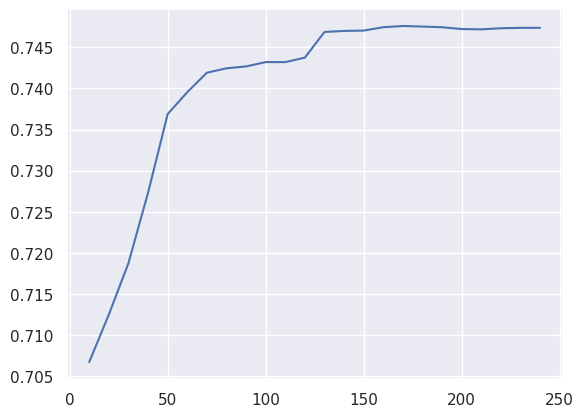

In [ ]:
stat_n_comp = []
ns = []
means=[]
stds = []
for i, l in score_n:
    l = np.array(l)
    ns.append(i)
    means.append(l.mean())
    stds.append(l.std())

print(ns, means, stds)
plt.plot(ns, means)

In [ ]:
transformer.fit(X_Train)
X_train = transformer.transform(X_Train)
X_test = transformer.transform(X_Test)

clf = model.fit(X_train, y_Train)
print(roc_auc_score(y_Train, clf.decision_function(X_train)))
print(roc_auc_score(y_Test, clf.decision_function(X_test)))

0.7569256551684128
0.7492444824504364


Dado que no hay Overfitting, entrenaremos sobre todo el conjunto de entrenamiento (req_train_filtered_df) para finalmente evaluar nuestro modelo en el conjunto test.

In [ ]:
transformer.fit(master_table)
column_names = transformer.get_feature_names_out()
print("N° de columnas: ", column_names.shape)

t = transformer.transform(master_table)
if scipy.sparse.issparse(t):
    t = t.toarray()
master = pd.DataFrame(data=t, columns = column_names)
master

N° de columnas:  (249,)


,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,CNT_FAM_MEMBERS,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,...,FLAG_DOCUMENT_13_1,FLAG_DOCUMENT_14_1,FLAG_DOCUMENT_15_1,FLAG_DOCUMENT_16_1,FLAG_DOCUMENT_17_1,FLAG_DOCUMENT_18_1,FLAG_DOCUMENT_19_1,FLAG_DOCUMENT_20_1,FLAG_DOCUMENT_21_1,TARGET
0,-0.354962,0.565495,0.260681,0.348515,-1.062092,-1.857000,-0.179764,1.495787,0.005347,0.622625,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.668229,0.130080,-0.064241,0.117873,-0.139702,0.478687,-0.179764,0.770290,1.650376,-0.571749,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.354962,-0.960624,-0.283672,-0.950366,-1.078541,1.082093,-1.280703,-1.021304,0.622081,-0.571749,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.026249,0.168377,0.455070,0.348515,-0.078365,-1.701401,-0.179764,0.758939,0.942152,-0.571749,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.435137,0.725502,1.237637,0.955469,-0.775951,0.666312,-1.280703,1.386672,1.880488,-0.571749,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129036,-0.578724,-1.225504,-1.085020,-1.205287,-0.139702,-0.059250,-0.179764,0.267371,-0.520449,0.224500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
129037,-0.354962,0.433123,0.402795,0.348515,-0.931523,0.791302,-0.179764,-2.084910,-1.481594,-0.571749,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
129038,-0.354962,-1.001584,-1.188319,-0.926088,-0.981894,0.873778,-0.179764,-0.224511,0.789791,0.622625,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
129039,-0.354962,-0.243906,-0.394170,-0.246300,1.861234,0.559179,0.921175,1.131334,-0.924211,-0.571749,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Entrenemos el modelo.

In [ ]:
model = LogisticRegression(random_state=0, class_weight='balanced')

X_Train = master.drop(columns='TARGET')
y_Train = master['TARGET']

clf = model.fit(X_Train, y_Train)
print(clf.score(X_Train,y_Train))
print(roc_auc_score(y_Train, clf.decision_function(X_Train)))

0.694515696561558
0.7564040137094304


## Testing

Ahora, transformemos el conjunto test de acuerdo al conjunto de entrenamiento y creemos el archivo submission.csv

In [ ]:
tablita3=request_test_filtered_df.join(tablita.drop(columns='SK_ID_CURR'), how='left')
tablita3['TARGET']=0
tablita3 = tablita3.fillna(0)
column_names = transformer.get_feature_names_out()
master_test = pd.DataFrame(data=transformer.transform(tablita3).toarray(), columns = column_names)

X_Test = master_test.drop(columns='TARGET')

In [ ]:
tablita3['TARGET'] = clf.predict_proba(X_Test)[:,1]
Serie = tablita3['TARGET'].reset_index()
Serie.to_csv('submissionF3.csv', index=False)

In [ ]:
Serie

,SK_ID_CURR,TARGET
0,251482,0.221734
1,152322,0.479245
2,213864,0.161378
3,149195,0.526638
4,215443,0.433074
...,...,...
64573,449354,0.682651
64574,118433,0.236347
64575,177671,0.525439
64576,449847,0.618484
